# 3MTT CAPSTONE PROJECT:  
- ### *By:*  Gideon Silas

### Title: Crop Yield Prediction
This notebook demonstrates a full Scikit-Learn regression workflow, using crop yield data to predict harvest output

#### What I cover:
- Import the libraries/packages
- Getting the data ready
- Data cleaning and validation
- Exploratory Aata Analysis
- Feature preprocessing
- Choose and fit the model
- Evaluating the model
- Feature importance
- Summary & Findings

## Import the libraries/packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

#scikit-learn library
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error 
from sklearn.ensemble import RandomForestRegressor

# Loading the Data 

In [4]:
yield_df = pd.read_csv(r"C:\Users\USER\Downloads\yield_df.csv")

yield_df

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.00,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.00,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.00,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.00,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.00,16.37
...,...,...,...,...,...,...,...,...
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76


# Data Information

In [6]:
# Check shape

yield_df.shape

(28242, 8)

In [7]:
# Check datatypes

yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [8]:
# Check for missing values

yield_df.isna().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [9]:
# Check for duplicates

yield_df.duplicated().sum()

0

In [10]:
# Summary statistics

yield_df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


### Insights from summary statistics:

For hg/ha_yield (target variable):
- Maximum of 501,412 against Minimum of 50 shows us a massive range (almost 10,000x difference)
- Mean (77,052) is much more than the median/50% (38,295)

For pesticides:
- It ranges from 0.04 to 367,778, indicating vastly more use of pesticides in tones by most major countries.

## Hist plotting

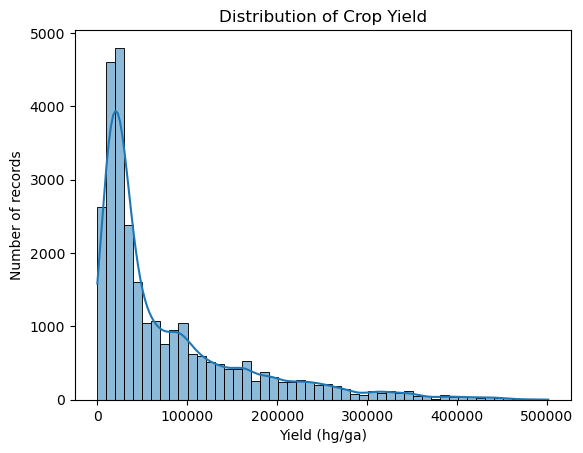

In [14]:
sns.histplot(yield_df["hg/ha_yield"], bins=50, kde = True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (hg/ga)")
plt.ylabel("Number of records")

plt.show()

From the Distribution of Crop Yield (hg/ha_yield), the Histogram shows that crop yield is right-skewed, indicating most records cluster at lower yield values (below 100,000 hg/ha), while a small number of records stretch out toward much higher values (up to 500,000 hg/ha).

This long tail is largely driven by differences in crop type, as detail below:

In [16]:
# Average yield per crop

yield_df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending= False)

Item
Potatoes                199801.549579
Cassava                 150479.466993
Sweet potatoes          119057.793772
Yams                    114140.345927
Plantains and others    106041.320144
Rice, paddy              40730.434770
Maize                    36310.070614
Wheat                    30116.267825
Sorghum                  18635.777229
Soybeans                 16731.092771
Name: hg/ha_yield, dtype: float64

### Insight: 
There is a clear split. 

Tubers (potatoes, cassava, sweet potatoes, yams) yield 5 to 10x more per hectare than grains (wheat, sorghum) or legumes (soybeans).

### Bar chart of average yield by crop

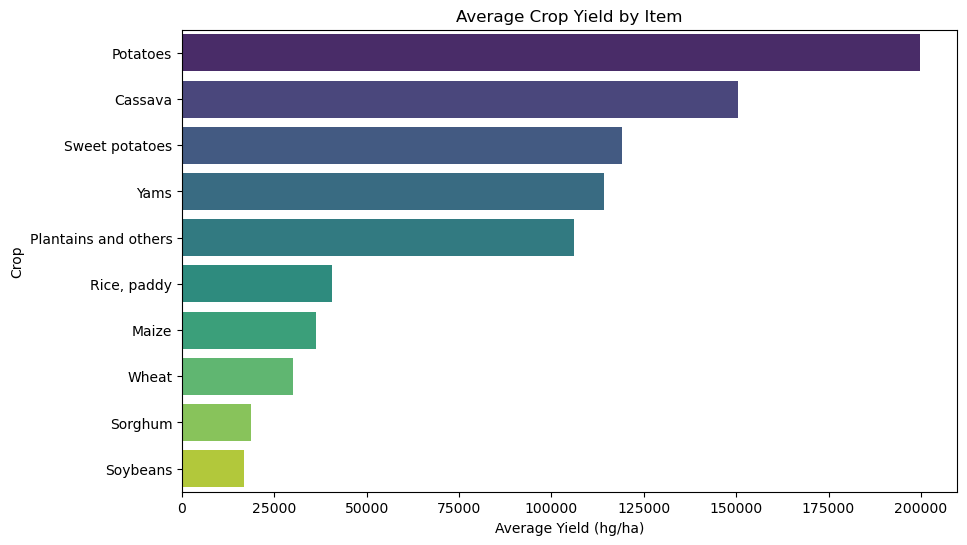

In [19]:
plt.figure(figsize = (10, 6))
avg_yield = yield_df.groupby("Item")["hg/ha_yield"].mean().sort_values(ascending= False)

sns.barplot(x = avg_yield.values, y = avg_yield.index, palette = "viridis")

plt.title("Average Crop Yield by Item")
plt.xlabel("Average Yield (hg/ha)")
plt.ylabel("Crop")

plt.show()

This visual confirms a clear split between two groups of crops. Tubers and root crops (Potatoes, Cassava, Sweet potatoes, Yams) and Plantains sit at the top, yielding well above 100,000 hg/ha on average. Grains and legumes (Rice, Maize, Wheat, Sorghum, Sorbeans) form a second, much lower tier, all under 45,000 hg/ha.

This 5x  gap reflects biological differences in how these crops grow rather than data quality issues. This can confirm that Item (crop type) may likely be one of the strongest predictors of yield in the model.

## Correlation Heatmap

In [ ]:
# Using Heatmap

plt.figure(figsize=(8, 6))
corr = yield_df[["hg/ha_yield", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]].corr()

sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap")

plt.show()

## Correlation within a single crop

In [ ]:
maize = yield_df[yield_df["Item"] == "Maize"]
maize[["hg/ha_yield", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]].corr()

### Insight:
This is a big insight. It shows that relationships between climate and yield only become visible once separated by crop type. Pooling all crops together hides real signal.

In [ ]:
# Checking one more crop for contrast

wheat = yield_df[yield_df["Item"] == "Wheat"]
wheat[["hg/ha_yield", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]].corr()

### Insight:
Across two different crops, Maize and Wheat, they have the same consistent pattern: temperature is the strongest (though still moderate) climate factor for yield, and its always negative. Rainfall and Pesticides stay weak in both.

In [ ]:
yield_df.head()

### Understanding value counts

In [ ]:
yield_df["Area"].value_counts()

In [ ]:
yield_df["Item"].value_counts()

In [ ]:
yield_df["Year"].value_counts().sort_index()

# Data Preprocessing

In [ ]:
yield_df.head()

# Label Encoding

In [ ]:
X_lab = LabelEncoder()
y_lab = LabelEncoder()

yield_df["Item_encoded"] = X_lab.fit_transform(yield_df["Item"])
yield_df["Area_encoded"] = y_lab.fit_transform(yield_df["Area"])

In [ ]:
yield_df.sample(5)

# Drop the redundant original columns

In [ ]:
X = yield_df.drop(columns=["hg/ha_yield", "Unnamed: 0", "Area", "Item"])

y = yield_df["hg/ha_yield"]

In [ ]:
X.sample(5)

In [ ]:
y.head()

# Feature Correlation

In [ ]:
# Using Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(X.corr(), annot=True)

plt.show()

### Insight:
There is no majore redundancy problem here. All the numbers are quite low, mostly between between -0.31 and 0.31.

# Feature Scaling

In [ ]:
# Create an instance first

scaler = StandardScaler()

scaledX = scaler.fit_transform(X)

In [ ]:
scaledX

In [ ]:
y

# Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size = 0.2, random_state=42)

In [ ]:
X_train.shape

In [ ]:
X_test.shape

# Random Forest

In [ ]:
#create an instance

forest_reg = RandomForestRegressor()

In [ ]:
#fit the instance to the training set

forest_reg.fit(X_train, y_train)

## Evaluate on the test set

In [ ]:
#predict on the test set

forest_preds = forest_reg.predict(X_test)

forest_preds

### Find r2_score

In [ ]:
#find r2_score

r2_score(y_test, forest_preds)

#### Find Error

In [ ]:
#find RMSE

np.sqrt(mean_squared_error(y_test, forest_preds))

# Extracting Feature Importance

In [ ]:
importances = pd.DataFrame(forest_reg.feature_importances_, index = X.columns, columns = ["Importance"])
importances = importances.sort_values(by = "Importance", ascending =False)

importances

## Bar chart of my feature importances

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(x = importances["Importance"], y =importances.index, palette ="viridis")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Summary & Findings
The project featured a complete machine learning workflow, starting with data exploration and ending with a predictive model. The most important findings include:

1. First, it was found that the data provided for the study had no missing values and duplicates. This was the first advantage of the data set
2. Yield distribution was found to be skewed to the right significantly, with several types of crops associated with abnormally high production
3. Climate change affects production in a way that is almost invisible if all the crops are considered together. However, for each individual crop, the relationship can be observed visually, and it is linear.
4. Using Random Forest Regression, it was possible to predict the yield with a high degree of accuracy (R squared = 0.986) using only six inputs.
5. It was found that the crop type was the most important factor in the prediction model, followed by climate change and the amount of pesticides used.